# 04 — District Capacity Index and Inequality Analysis

WHO SDG 3.c.1-style clinical workforce density (doctors + nurses + midwives per 10,000 population) per kabupaten, and whether flood disruption hit underserved districts harder. Full discussion in `../docs/phase2_summary.md` and `../docs/sentinel1_validated_results.md`.

In [1]:
import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PROC = Path('../data/processed')
capacity = gpd.read_file(DATA_PROC / 'kabupaten_capacity_index.geojson')
capacity[['kabupaten', 'population_2020', 'clinical_staff', 'clinical_staff_per_10k', 'capacity_class']]\
    .sort_values('clinical_staff_per_10k')

,kabupaten,population_2020,clinical_staff,clinical_staff_per_10k,capacity_class
3,Barito Kuala,331247.750000,816,24.634130,underserved
1,Kotabaru,400543.406250,997,24.891185,underserved
2,Banjar,648102.812500,1954,30.149537,underserved
0,Tanah Laut,396134.531250,1248,31.504449,underserved
4,Tapin,231151.375000,764,33.051934,underserved
8,Tabalong,276634.531250,958,34.630528,underserved
9,Tanah Bumbu,387199.968750,1535,39.643598,well-served
7,Hulu Sungai Utara,209030.562500,857,40.998789,well-served
6,Hulu Sungai Tengah,262395.250000,1077,41.044950,well-served
12,Kota Banjarbaru,286467.406250,1247,43.530258,well-served


## Capacity choropleth

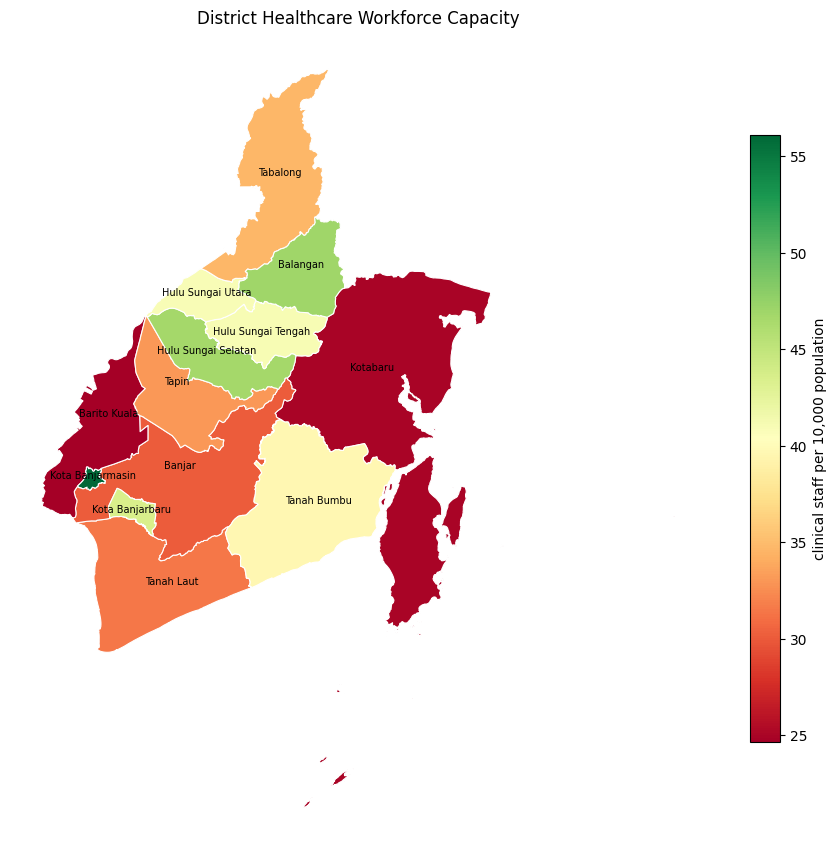

In [2]:
fig, ax = plt.subplots(figsize=(9, 9))
capacity.plot(ax=ax, column='clinical_staff_per_10k', cmap='RdYlGn', legend=True,
              edgecolor='white', linewidth=0.8,
              legend_kwds={'label': 'clinical staff per 10,000 population', 'shrink': 0.7})
for _, row in capacity.iterrows():
    c = row.geometry.representative_point()
    ax.annotate(row['kabupaten'], (c.x, c.y), fontsize=7, ha='center')
ax.set_title('District Healthcare Workforce Capacity')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Inequality: access change by capacity, real (Sentinel-1) disruption

In [3]:
per_kab = pd.read_csv(DATA_PROC / 'inequality_sentinel1_per_kabupaten.csv')
per_kab = per_kab.sort_values('capacity_per_10k')
per_kab

,kabupaten,capacity_per_10k,baseline_within60_pct,s1_moderate_within60_pct,s1_severe_within60_pct,pp_drop_moderate
0,Barito Kuala,24.634130,84.760159,59.538974,0.000000,25.221185
1,Banjar,30.149537,73.986559,66.716403,0.000000,7.270156
2,Tanah Laut,31.504449,83.910544,83.645397,0.000000,0.265147
3,Tapin,33.051934,82.943476,77.535838,0.000000,5.407637
4,Tabalong,34.630528,75.584764,74.656275,0.000000,0.928489
5,Tanah Bumbu,39.643598,71.060764,69.553230,35.869985,1.507535
6,Hulu Sungai Utara,40.998789,83.042056,82.338466,0.000000,0.703590
7,Hulu Sungai Tengah,41.044950,94.087830,88.671591,0.000000,5.416239
8,Hulu Sungai Selatan,46.741326,82.618171,80.302982,0.000000,2.315189
9,Balangan,46.935207,70.357469,65.503512,0.000000,4.853957


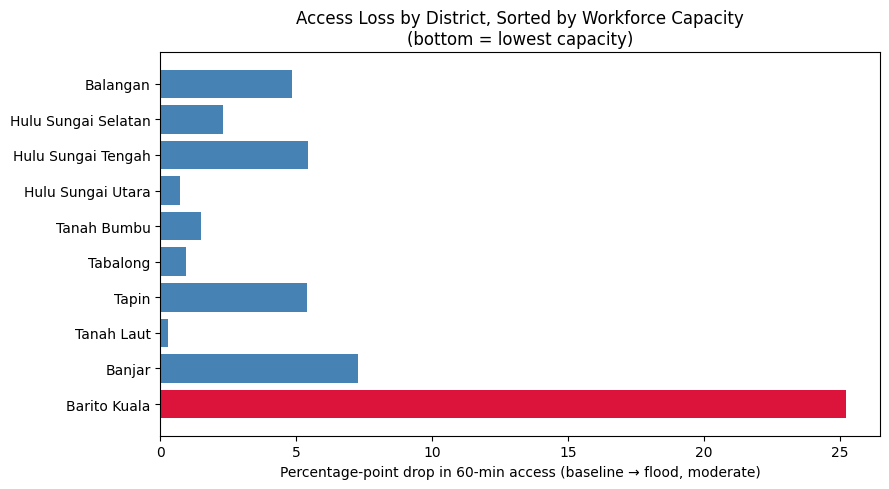

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['crimson' if d > 10 else 'steelblue' for d in per_kab['pp_drop_moderate']]
ax.barh(per_kab['kabupaten'], per_kab['pp_drop_moderate'], color=colors)
ax.set_xlabel('Percentage-point drop in 60-min access (baseline → flood, moderate)')
ax.set_title('Access Loss by District, Sorted by Workforce Capacity\n(bottom = lowest capacity)')
plt.tight_layout()
plt.show()

## Capacity vs. access loss — correlation check

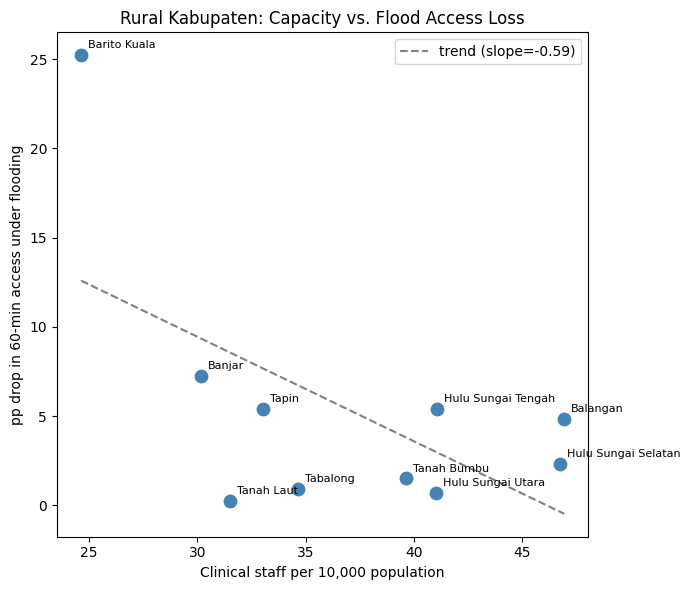

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(per_kab['capacity_per_10k'], per_kab['pp_drop_moderate'], s=80, color='steelblue')
for _, row in per_kab.iterrows():
    ax.annotate(row['kabupaten'], (row['capacity_per_10k'], row['pp_drop_moderate']),
                fontsize=8, xytext=(5, 5), textcoords='offset points')
z = np.polyfit(per_kab['capacity_per_10k'], per_kab['pp_drop_moderate'], 1)
xs = np.linspace(per_kab['capacity_per_10k'].min(), per_kab['capacity_per_10k'].max(), 50)
ax.plot(xs, np.poly1d(z)(xs), '--', color='gray', label=f'trend (slope={z[0]:.2f})')
ax.set_xlabel('Clinical staff per 10,000 population')
ax.set_ylabel('pp drop in 60-min access under flooding')
ax.set_title('Rural Kabupaten: Capacity vs. Flood Access Loss')
ax.legend()
plt.tight_layout()
plt.show()